### Heat Equation.

The Heat Equation in one spatial dimension is given as below :

$$ u_t = \alpha u_{xx} $$

Let's solve this PDE in the domain :

$$ x\in [0,1] $$
$$ t\in [0,1] $$

with the initial condition :

$$ u(x,0) = \sin(\pi x) $$

and boundary conditions :

$$ u(0,t) = u(1,t) = 0 $$

### Exact Solution.

The exact solution for the problem above is given by :

$$ u(x,t) = e^{-\alpha \pi^2 t}\sin(\pi x) $$

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
# parameters
alpha = 1.0

In [3]:
# domain
N_x, N_t = 51, 51
x = torch.linspace(0.0,1.0,N_x,requires_grad=True)
t = torch.linspace(0.0,1.0,N_t,requires_grad=True)

x_mesh, t_mesh = torch.meshgrid(x,t)
print(x_mesh.shape, t_mesh.shape)

torch.Size([51, 51]) torch.Size([51, 51])


C:\Users\ANUNAY CHANDRA\AppData\Roaming\Python\Python310\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [4]:
input = torch.column_stack((x_mesh.flatten(),t_mesh.flatten()))
print(input.shape)

torch.Size([2601, 2])


In [5]:
# model
model = nn.Sequential(
    nn.Linear(2,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [6]:
# Defining the loss function
def Loss(model, x_mesh, t_mesh, x, t, input):
    u = model(input).reshape(N_x,N_t)

    # partial derivatives
    dudt = torch.autograd.grad(
        outputs = u,
        inputs = t_mesh,
        create_graph=True,
        grad_outputs=torch.ones_like(u)
    )[0]

    dudx = torch.autograd.grad(
        outputs = u,
        inputs = x_mesh,
        create_graph=True,
        grad_outputs=torch.ones_like(u)
    )[0]

    d2udx2 = torch.autograd.grad(
        outputs = dudx,
        inputs = x_mesh,
        create_graph=True,
        grad_outputs=torch.ones_like(u)
    )[0]

    # pde loss
    loss_pde = torch.mean((dudt - alpha * d2udx2)**2)

    # boundary loss
    loss_bc = torch.mean((u[0,:])**2 + (u[-1,:])**2)

    # initial condition loss
    loss_ic = torch.mean((u[:,0] - torch.sin(torch.pi*x))**2)

    return loss_pde + loss_bc + loss_ic

In [7]:
# optimizer
optim = torch.optim.Adam(model.parameters(), lr = 0.001)

In [8]:
# training the model
N_epoch = 10000
loss_arr = []
for epoch in range(N_epoch):
    loss = Loss(model, x_mesh, t_mesh, x, t, input)
    loss_arr.append(loss.item())
    loss.backward()
    optim.step()
    optim.zero_grad()

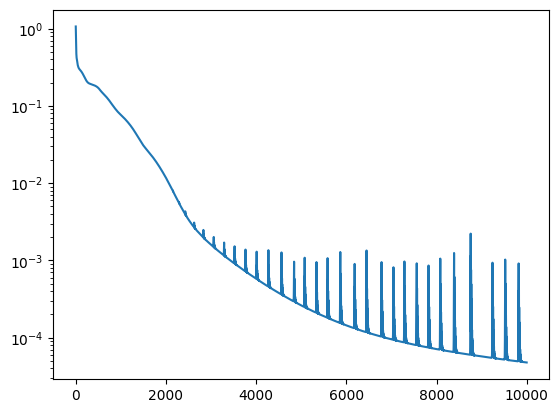

In [9]:
# loss visualisation
plt.semilogy(loss_arr)
plt.show()

In [10]:
# exact function
with torch.no_grad():
    u_exact = torch.exp(-alpha * torch.pi**2 * t_mesh) * torch.sin(torch.pi * x_mesh)
    u_nn = model(input).reshape(N_x,N_t)

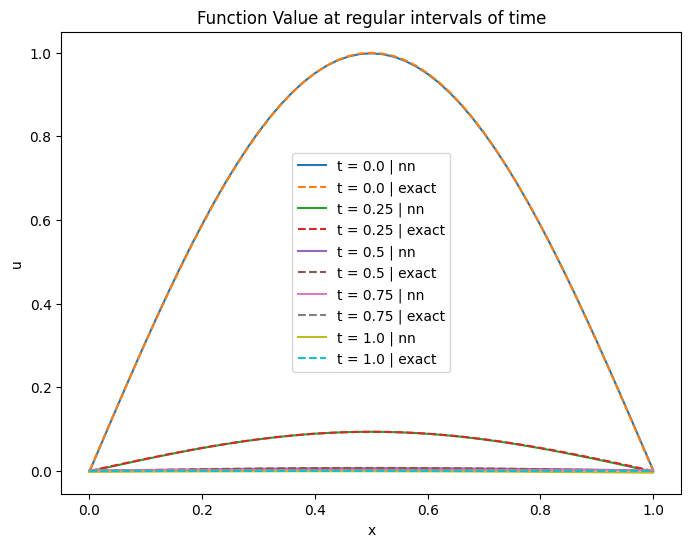

In [23]:
# visualising u(x,t) at fixed intervals of time
times = [0.0, 0.25, 0.5, 0.75, 1.0]
plt.figure(figsize = (8,6))

for time in times:
    index = int(time/(1.0/(N_t-1)))
    # print(time,index)
    plt.plot(x.detach().flatten(),u_nn[:,index].detach().flatten(),label = f't = {time} | nn')
    plt.plot(x.detach().flatten(),u_exact[:,index].detach().flatten(),label = f't = {time} | exact', ls = '--')
plt.legend()
plt.title("Function Value at regular intervals of time")
plt.xlabel("x")
plt.ylabel("u")
plt.show()

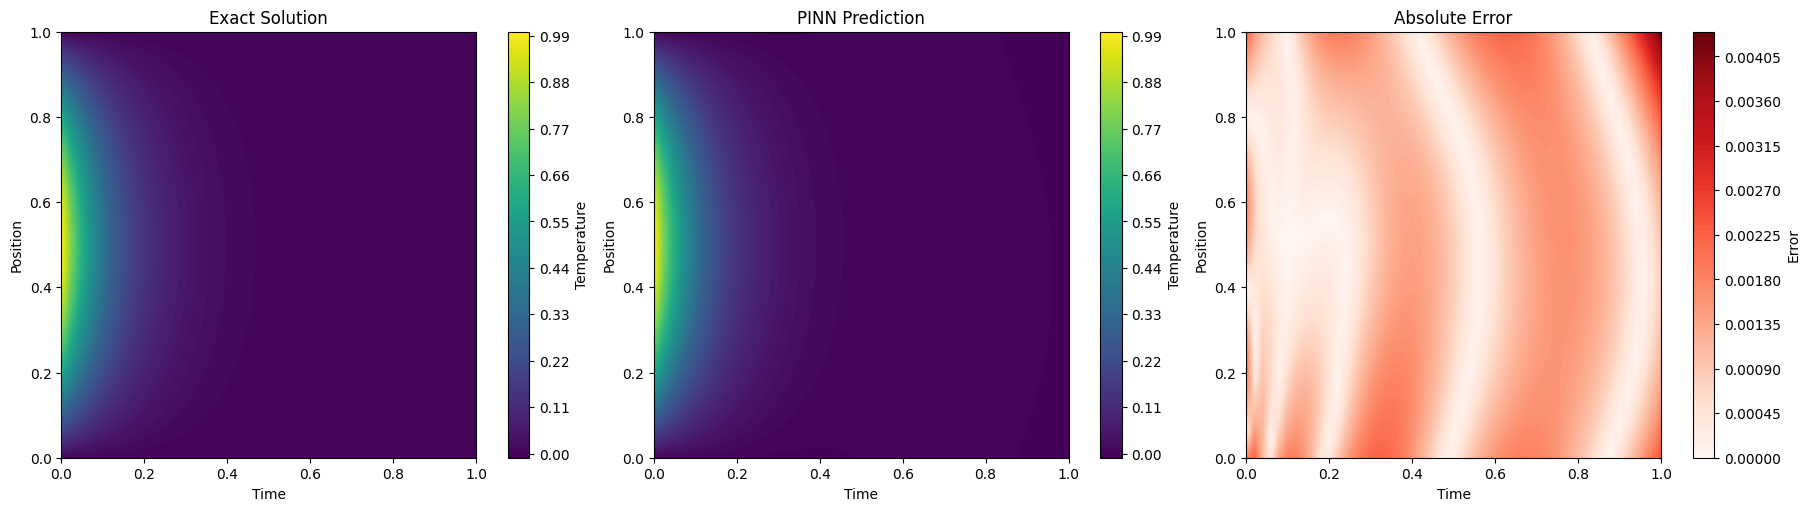

In [27]:
error = torch.abs(u_nn - u_exact)

fig, ax = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Exact solution
c1 = ax[0].contourf(
    t_mesh.detach(),
    x_mesh.detach(),
    u_exact.detach(),
    levels=100,
    cmap="viridis"
)
ax[0].set_title("Exact Solution")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Position")
fig.colorbar(c1, ax=ax[0], label="Temperature")

# PINN prediction
c2 = ax[1].contourf(
    t_mesh.detach(),
    x_mesh.detach(),
    u_nn.detach(),
    levels=100,
    cmap="viridis"
)
ax[1].set_title("PINN Prediction")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Position")
fig.colorbar(c2, ax=ax[1], label="Temperature")

# Absolute error
c3 = ax[2].contourf(
    t_mesh.detach(),
    x_mesh.detach(),
    error.detach(),
    levels=100,
    cmap="Reds"
)
ax[2].set_title("Absolute Error")
ax[2].set_xlabel("Time")
ax[2].set_ylabel("Position")
fig.colorbar(c3, ax=ax[2], label="Error")

plt.show()